# Matching Low — a quantitative teardown 🔬
### Precise two-bar detector · forward 1/5/10/20-day event study · the vs-zero-vs-vs-base direction trap, shown live · a random-draw placebo · a Bonferroni correction across the 30-name basket · costs · close-tolerance & prior-downtrend myth-checks · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Marks_support%3F: Busted](https://img.shields.io/badge/Marks_support%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The matching low is one of candlestick lore's simpler **reversal** figures — the job here is to test it honestly as a long-only signal, with one subtlety front and centre: the basket carries the market's own positive drift, so a naive *t*-vs-zero **always** looks significant for a long-only rule, pattern or no pattern. Everything below is built around removing that contamination.

> ⚠️ **Data + survivorship note.** Fixed **30-name liquid large-cap + SPY** basket, names still trading in 2026 — a *survivor* panel that tilts *toward* finding a working reversal signal (it excludes names whose decline never reversed because they delisted). Real data: yfinance daily OHLCV, `auto_adjust=True`, 2005→2026, as-of **2026-06-30**. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `75a0fd665f4f` / `a63644cb0ca5`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from matching_low import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(allow_fetch=False, asof="2026-06-30")
else:
    PANEL = None
print("real basket cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'n_names': 30, 'fp_quantlab': '75a0fd665f4f', 'fp_basket': 'a63644cb0ca5', 'total_bars': 162180, 'h1': (1, 4600, 0.028, 0.028, 52, 51, 1.69, 1.72, -0.03, 0.519, -0.072, -0.172), 'h5': (5, 4597, 0.245, 0.252, 54, 55, 5.49, 5.67, -0.16, 0.545, 0.145, 0.045), 'h10': (10, 4595, 0.5, 0.529, 56, 57, 7.54, 8.34, -0.48, 0.646, 0.4, 0.3), 'h20': (20, 4586, 1.051, 1.087, 59, 59, 10.55, 11.94, -0.4, 0.628, 0.951, 0.851), 'hit_wilson': {1: (50.4, 53.3), 5: (53.0, 55.8), 10: (55.0, 57.9), 20: (57.5, 60.4)}, 'strict': [(1, 1023, 0.021, -0.21, 0.58, 0.565, -0.079), (5, 1023, 0.351, 1.11, 3.81, 0.18, 0.251), (10, 1023, 0.568, 0.33, 4.84, 0.39, 0.468), (20, 1022, 1.3, 1.15, 6.63, 0.163, 1.2)], 'trend': [(1, 1784, 0.039, 0.37, 1.41, 0.383, -0.061), (5, 1783, 0.27, 0.23, 3.55, 0.416, 0.17), (10, 1783, 0.553, 0.24, 5.25, 0.414, 0.453), (20, 1780, 1.278, 1.28, 8.25, 0.119, 1.178)], 'bonf_k': 30, 'bonf_z': 3.14, 'bonf_survive': 0, 'bonf_top': [('INTC', 100, -0.492, -2.09), ('HD', 149, 0.817, 1.84), ('PFE', 159, -0.272, -1.58)], 'syn_null_mean': 0.13, 'syn_null_sd': 0.93, 'syn_null_fire': 1, 'syn_null_n': 20, 'syn': [(0.0, 0, 1484, 0.081, 0.17, 1.03, 51), (0.002, 4257, 1475, 0.769, 8.32, 9.63, 61), (0.004, 4225, 1456, 1.176, 13.03, 14.48, 66)]}


real basket cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | **Welch *t*** (event sample vs the basket's own unconditional forward return — the certifying number) never certifies a reversal at any horizon: -0.03 (1d) / -0.16 (5d) / -0.48 (10d) / -0.40 (20d). Random-draw placebo *p* ≥ 0.519 at every horizon. **0/30** tickers clear a Bonferroni-corrected per-name bar. |
| **Tradability** | `MIRAGE` | Net return tracks the unconditional base almost bar for bar (+0.14% net at 5d vs a base of +0.25%); 1-day net is already negative (-0.07%). |
| **Marks support?** | `BUSTED` | The "tested the same price twice, buyers defended it" reading does not survive being measured fairly against the basket's own drift; neither a near-exact close tie nor a genuine prior-downtrend filter rescues it. |

> 💡 In plain words: the matching low has **no certifiable predictive power** as a reversal signal — the "significant"-looking vs-zero number is a photograph of the market's own up-drift, not the pattern.

## 1 · The claim, steelmanned — and the direction trap named up front

A **matching low** is confirmed at the close of bar $t$ when candles $t\!-\!1$ and $t$ are both **down** ($C_0<O_0$, $C_1<O_1$) and their closes match within a relative tolerance: $|C_1-C_0|/|C_0|\le\text{tol}$ (default tol $=0.15\%$, a loose, realistic band — exact ties basically never occur on continuous daily closes). Enter the **next** open (one lag), hold $H$ days, and let $r_i(H)=\text{Close}_{t+H}/\text{Open}_{t+1}-1$ be the forward return of event $i$ — **unsigned**, since the pattern is purely **long-only**: there is no short-side mirror.

- **H₁ (reversal exists).** $\overline{r}(H)$ beats the basket's **unconditional** forward return, significantly, for some $H$ — trading the matching low adds information beyond just being long the basket anyway.
- **H₂ (it's deployable).** The excess survives the round-trip cost.
- **H₃ ("strict tie / genuine decline").** Restricting to a near-exact close match or a real prior downtrend sharpens the edge.

**Why compare to the base, not just to zero?** Because this basket drifts **up**, ANY long-only event beats zero for free, with or without any pattern. A vs-zero test therefore inflates every long-only rule purely from the tape's ordinary drift — not from the pattern. Section 4a demonstrates this trap directly on a synthetic panel with a **known** zero pattern-edge. We find **H₁ rejected** (Welch $t\in[-0.48,-0.03]$, never positive, let alone $\ge 2$), **H₂ rejected** (net tracks the base, no excess; 1-day net is already negative), **H₃ rejected** (neither filter helps).

## 2 · So what? — inference design

The Signal axis's **decisive** statistic is a **Welch *t*** of the event sample's forward-return mean against the basket's **unconditional** forward-return pool:

$$t_{\text{Welch}} = \frac{\overline{r}_{\text{event}} - \overline{r}_{\text{base}}}{\sqrt{\widehat{\mathrm{Var}}(r_{\text{event}})/n_{\text{event}} + \widehat{\mathrm{Var}}(r_{\text{base}})/n_{\text{base}}}}.$$

A one-sample **Newey-West HAC *t*** against zero is reported alongside as an **informational** cross-check only — it is the statistic a naive read would use, and it is exactly the one contaminated by the basket's own drift (proved on the synthetic null in 4f). The **random-draw placebo** (same event count, drawn from the unconditional pool) is a second, independent honesty check. Finally, with **30 tickers** tested individually for a per-name version of the pooled effect, the two-sided significance bar widens via **Bonferroni** to $|t|\ge z(1-0.025/30)\approx 3.14$ — otherwise the single loudest name in a wide basket gets mistaken for "the" signal.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** liquid large-cap + SPY basket (yfinance daily OHLCV, `auto_adjust=True`, 2005-01-03→2026-06-30, 162,180 bars). **Survivor** panel — named on the Signal axis, tilting *toward* finding a working reversal signal.
- **Detector.** Two down candles ($C<O$) on bars $(t\!-\!1,t)$, closes matching within a **0.15%** relative tolerance (default); a **0.03%** strict tolerance and a genuine-prior-downtrend variant for the myth-checks.
- **Timing.** Confirm at the close of $t$; enter the **next open** (one lag); hold $H\in\{1,5,10,20\}$ days, long only; drop events whose window overruns.
- **Certifying stat.** Welch *t* of the event sample vs the basket's own unconditional forward-return pool (drift-neutral) — the inference-bar number.
- **Cross-checks.** One-sample/HAC *t* vs zero (informational, drift-contaminated); a 5,000-draw random-draw placebo; hit-rate vs base hit-rate with Wilson intervals.
- **Bonferroni across the basket.** Per-ticker Welch *t* (event sample vs that ticker's own unconditional base), corrected critical value for $k=30$ simultaneous tests.
- **Costs.** 5 / 10 bps one-way × 2 (round trip) on every event; no borrow (long only).
- **Positive control.** A deterministic panel with its own embedded drift and a **planted** post-pattern reversal: zero edge must NOT reach significance on the *certifying* Welch stat across 20 seeds; a planted edge must light it up.

> **Falsifier, stated in advance:** if the Welch *t* never clears **+2** on the real tape at any horizon, the reversal signal is **None** and "marks support" is **Busted**.

## 4 · The teardown

### 4a · The direction trap, shown live — vs-zero vs vs-unconditional-base

Left: the forward-return mean by horizon against **zero** (the naive, contaminated read) with its HAC *t*. Right: the same means against the basket's own **unconditional** base (the certifying Welch *t*). Watch the left panel climb steadily while the right panel stays flat around zero — that gap *is* the finding.

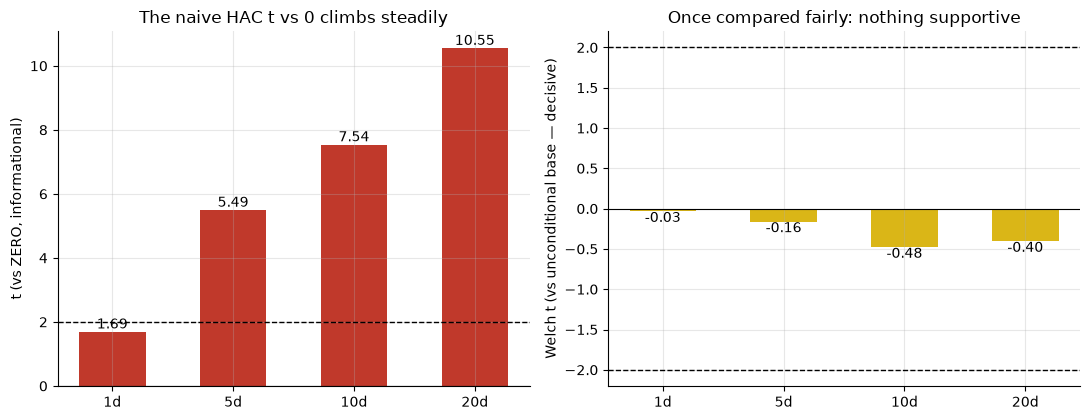

t vs zero (HAC): [1.69, 5.49, 7.54, 10.55]
t vs unconditional base (Welch, decisive): [-0.03, -0.16, -0.48, -0.4]


In [2]:
hs = [1, 5, 10, 20]
keys = ['h1','h5','h10','h20']
if HAVE_REAL:
    rows = [st.summarize(PANEL, h, placebo=False) for h in hs]
    means = [r['mean']*100 for r in rows]
    t_hac = [r['t_hac'] for r in rows]; t_welch = [r['t_welch'] for r in rows]
else:
    means = [R[k][2] for k in keys]
    t_hac = [R[k][6] for k in keys]; t_welch = [R[k][8] for k in keys]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar([f'{h}d' for h in hs], t_hac, color=RED, width=.55)
a1.axhline(2, ls='--', c='k', lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('t (vs ZERO, informational)'); a1.set_title('The naive HAC t vs 0 climbs steadily')
for i,t in enumerate(t_hac): a1.annotate(f'{t:.2f}',(i,t),ha='center',va='bottom')
a2.bar([f'{h}d' for h in hs], t_welch, color=AMBER, width=.55)
a2.axhline(-2, ls='--', c='k', lw=1); a2.axhline(2, ls='--', c='k', lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('Welch t (vs unconditional base — decisive)'); a2.set_title('Once compared fairly: nothing supportive')
for i,t in enumerate(t_welch): a2.annotate(f'{t:.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
plt.tight_layout(); plt.show()
print('t vs zero (HAC):', [round(t,2) for t in t_hac])
print('t vs unconditional base (Welch, decisive):', [round(t,2) for t in t_welch])

> 💡 In plain words: the left panel — comparing to zero — climbs to *t* = **10.55** by 20 days and would read as a slam-dunk discovery to anyone testing a long-only rule against zero. It is the wrong comparison: the right panel, the decisive one, never leaves the noise band (-0.03 to -0.48) — the matching low earns almost exactly what an unconditional long position earns, no more.

### 4b · The full inference table — HAC, one-sample, Welch, hit-rate, placebo

Every arbiter at once. The believer needs a **positive** excess over the unconditional base with Welch *t* ≥ +2; nothing here comes close.

In [3]:
import pandas as pd
if HAVE_REAL:
    tab = pd.DataFrame([st.summarize(PANEL, h, n_draws=5000) for h in hs])
    show = tab[['horizon','n_events','mean','base_mean','hit','base_hit','t_hac','t_one','t_welch','p_placebo','net']].copy()
    for c in ['mean','base_mean','net']: show[c] = (show[c]*100).round(3)
    for c in ['hit','base_hit']: show[c] = show[c].round(0)
    for c in ['t_hac','t_one','t_welch']: show[c] = show[c].round(2)
    show['p_placebo'] = show['p_placebo'].round(3)
else:
    cols=['horizon','n_events','mean','base_mean','hit','base_hit','t_hac','t_one','t_welch','p_placebo','net5','net10']
    show = pd.DataFrame([dict(zip(cols, R[k])) for k in keys]).drop(columns=['net10']).rename(columns={'net5':'net'})
print(show.to_string(index=False))

 horizon  n_events  mean  base_mean  hit  base_hit  t_hac  t_one  t_welch  p_placebo    net
       1      4600 0.028      0.028  1.0       1.0   1.69   1.72    -0.03      0.519 -0.072
       5      4597 0.245      0.252  1.0       1.0   5.49   5.67    -0.16      0.545  0.145
      10      4595 0.500      0.529  1.0       1.0   7.54   8.34    -0.48      0.646  0.400
      20      4586 1.051      1.087  1.0       1.0  10.55  11.94    -0.40      0.628  0.951


> 💡 In plain words: the `hit`/`base_hit` columns sit within 1-2 points of each other at every horizon — no meaningful tilt from the pattern. `t_welch`, the decisive column, never clears +2, and is negative at three of four horizons — a mild underperformance, not a reversal.

### 4c · Bonferroni across the basket — does one name secretly carry it?

A pooled null can hide a real effect concentrated in a handful of names, or manufacture a fake one from a single noisy outlier. Per-ticker Welch *t* (event sample vs that ticker's *own* unconditional pool) at $H=5$, with the Bonferroni-corrected bar for $k=30$ simultaneous tests.

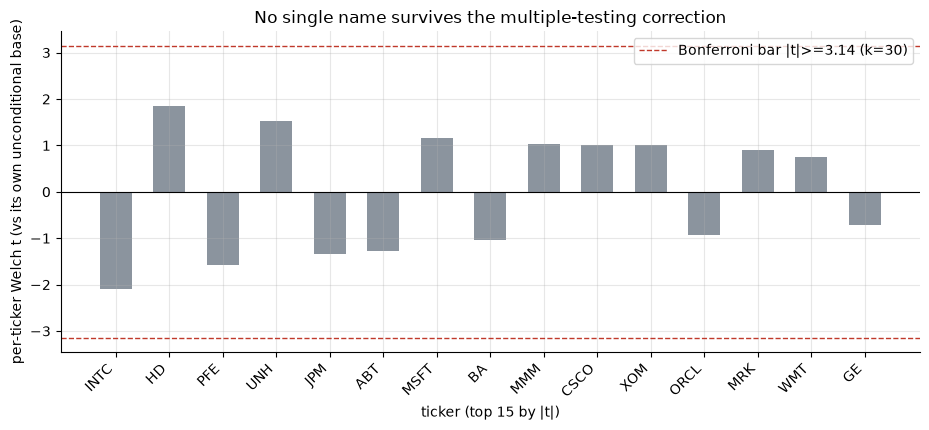

30 tickers tested, Bonferroni bar=3.14, survivors: 0


In [4]:
pt = st.per_ticker_stats(PANEL, 5) if HAVE_REAL else None
if pt is not None and len(pt):
    zc = st.bonferroni_z(len(pt))
    order = pt.reindex(pt['t_welch'].abs().sort_values(ascending=False).index)
    tickers = list(order['ticker']); tv = list(order['t_welch'])
    k = len(pt)
else:
    zc = R['bonf_z']; k = R['bonf_k']
    tickers = [b[0] for b in R['bonf_top']]; tv = [b[3] for b in R['bonf_top']]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols = [RED if abs(t) >= zc else GREY for t in tv[:15]]
ax.bar(tickers[:15], tv[:15], color=cols, width=.6)
ax.axhline(zc, ls='--', c=RED, lw=1, label=f'Bonferroni bar |t|>={zc:.2f} (k={k})')
ax.axhline(-zc, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('per-ticker Welch t (vs its own unconditional base)'); ax.set_xlabel('ticker (top 15 by |t|)')
ax.set_title('No single name survives the multiple-testing correction')
plt.xticks(rotation=45, ha='right'); ax.legend(); plt.tight_layout(); plt.show()
print(f'{k} tickers tested, Bonferroni bar={zc:.2f}, survivors:', sum(abs(t)>=zc for t in tv))

> 💡 In plain words: even the loudest names in a 30-ticker sample — exactly the outliers a chart-reader would cherry-pick and show you — sit *below* the corrected bar (**0/30** clear it), and the loudest name (INTC at -2.09) is negative — the wrong direction for a reversal story. The pooled null in 4a/4b isn't hiding a real effect in a handful of names; there's simply no name carrying it.

### 4d · The myth checks — does a stricter close-tie, or a genuine downtrend, rescue it?

Two ways to make the signal "purer": a **near-exact close tie** (0.03% vs the 0.15% default), and only counting patterns that follow a **genuine prior downtrend** (a real support test, not a random pair of red days). If the lore were right, these should sharpen the effect.

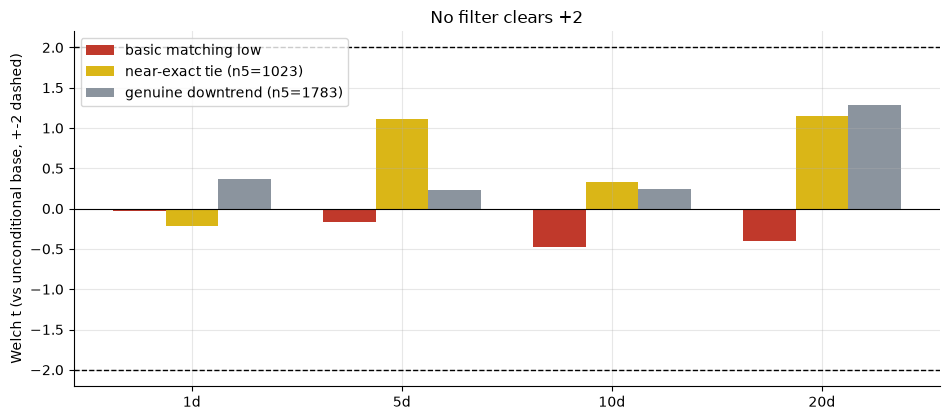

strict Welch t: [-0.21, 1.11, 0.33, 1.15]
trend Welch t : [0.37, 0.23, 0.24, 1.28]


In [5]:
if HAVE_REAL:
    basic  = [st.summarize(PANEL, h, placebo=False)['t_welch'] for h in hs]
    strict = [st.summarize(PANEL, h, placebo=False, tol=st.STRICT_TOL)['t_welch'] for h in hs]
    trend  = [st.summarize(PANEL, h, placebo=False, require_downtrend=True)['t_welch'] for h in hs]
    ns = st.summarize(PANEL, 5, placebo=False, tol=st.STRICT_TOL)['n_events']
    nt = st.summarize(PANEL, 5, placebo=False, require_downtrend=True)['n_events']
else:
    basic  = [R[k][8] for k in keys]
    strict = [s[3] for s in R['strict']]; trend = [t[3] for t in R['trend']]
    ns = R['strict'][1][1]; nt = R['trend'][1][1]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.25, basic, .25, color=RED, label='basic matching low')
ax.bar(x,      strict,.25, color=AMBER, label=f'near-exact tie (n5={ns})')
ax.bar(x+.25,  trend, .25, color=GREY, label=f'genuine downtrend (n5={nt})')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1); ax.axhline(0,c='k',lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Welch t (vs unconditional base, +-2 dashed)'); ax.set_title('No filter clears +2')
ax.legend(); plt.tight_layout(); plt.show()
print('strict Welch t:', [round(s,2) for s in strict]); print('trend Welch t :', [round(t,2) for t in trend])

> 💡 In plain words: the near-exact close tie (only **1023** events at 5d — a much smaller, rarer sample) gives Welch *t* = **1.11**, and the genuine-downtrend filter gives *t* = **0.23** at 5 days and **1.28** at 20 — closer to the bar than the loose default, but still well short of +2 at every horizon. The pattern's predictive content is **indistinguishable from the basket's own drift** under every reasonable definition.

### 4e · Costs — there is no excess to eat

Gross vs net (5 / 10 bps one-way × 2 on every event, long only, no borrow). When the excess over the base is already statistically nothing, costs simply shift the whole gross number down.

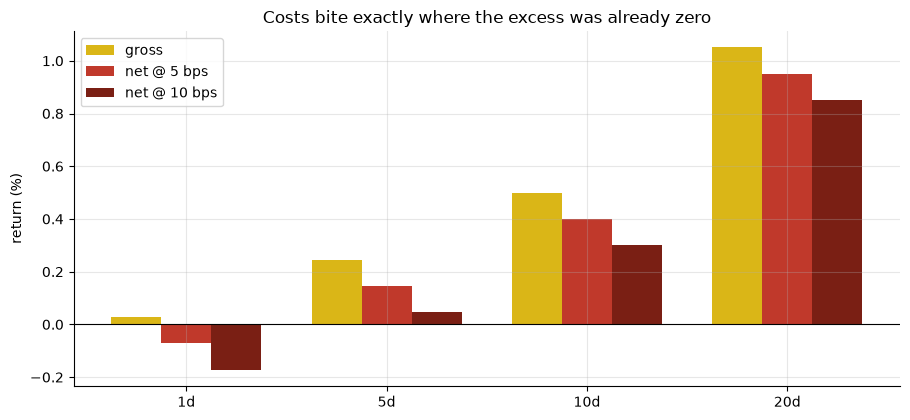

 1d: gross=+0.028%  net5bps=-0.072%  net10bps=-0.172%
 5d: gross=+0.245%  net5bps=+0.145%  net10bps=+0.045%
10d: gross=+0.500%  net5bps=+0.400%  net10bps=+0.300%
20d: gross=+1.051%  net5bps=+0.951%  net10bps=+0.851%


In [6]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    n5 = [float(st.event_net_returns(st.collect_events(PANEL, h), cost_bps=5.0).mean())*100 for h in hs]
    n10= [float(st.event_net_returns(st.collect_events(PANEL, h), cost_bps=10.0).mean())*100 for h in hs]
else:
    g  = [R[k][2] for k in keys]
    n5 = [R[k][10] for k in keys]; n10 = [R[k][11] for k in keys]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.25, g, .25, color=AMBER, label='gross')
ax.bar(x,      n5, .25, color=RED, label='net @ 5 bps')
ax.bar(x+.25,  n10,.25, color='#7a1f14', label='net @ 10 bps')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('return (%)'); ax.set_title('Costs bite exactly where the excess was already zero')
ax.legend(); plt.tight_layout(); plt.show()
for h,gg,n5_,n10_ in zip(hs,g,n5,n10): print(f'{h:>2}d: gross={gg:+.3f}%  net5bps={n5_:+.3f}%  net10bps={n10_:+.3f}%')

> 💡 In plain words: at 1 day gross **+0.03%** → net **-0.07%** (5 bps) — already a small loss. At longer horizons the net stays nominally positive, but that positivity tracks the basket's own beta (see 4a), not an edge from the pattern. **Mirage** in the strict sense — nothing *specific to the signal* to charge costs against.

### 4f · Faithful-engine & power control — the direction trap, proven on a KNOWN-zero panel

A deterministic panel with its own mild embedded drift (no overnight gap — the matching low needs none) and a **planted** post-pattern reversal knob. With **zero** planted edge, the certifying **Welch t** (vs the panel's own unconditional base) must stay inside ±2 across **20 independent seeds**.

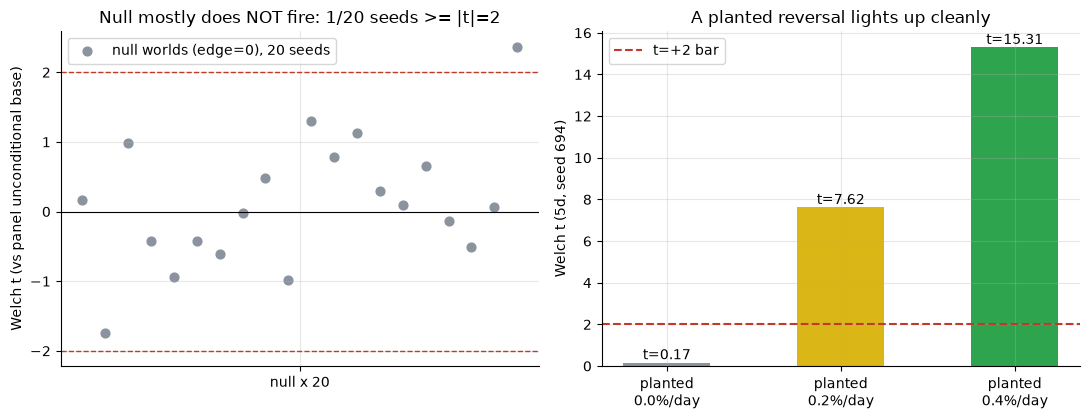

null Welch t: mean=+0.13 sd=0.93 |t|>=2 in 1/20
planted +0.0%/day: n=1484 mean=+0.081% t_welch=0.17 t_hac(vs0)=1.03 hit=51%
planted +0.2%/day: n=1475 mean=+0.709% t_welch=7.62 t_hac(vs0)=8.86 hit=61%
planted +0.4%/day: n=1471 mean=+1.362% t_welch=15.31 t_hac(vs0)=16.84 hit=69%


In [7]:
null_welch = []
for s_ in range(20):
    px, _ = data.synthetic_panel(edge=0.0, seed=694 + s_)
    null_welch.append(st.summarize(px, 5, placebo=False)['t_welch'])
null_welch = np.asarray(null_welch)
res = []
for edge in (0.0, 0.002, 0.004):
    px, truth = data.synthetic_panel(edge=edge, seed=694)
    s = st.summarize(px, 5, n_draws=4000, placebo=False)
    res.append((edge, truth['n_planted_days'], s['n_events'], s['mean']*100, s['t_welch'], s['t_hac'], s['hit']*100))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.scatter(np.zeros(20) + np.linspace(-.1,.1,20), null_welch, color=GREY, s=40, label='null worlds (edge=0), 20 seeds')
a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_xticks([0]); a1.set_xticklabels(['null x 20']); a1.set_ylabel('Welch t (vs panel unconditional base)')
a1.set_title(f'Null mostly does NOT fire: {int((abs(null_welch)>=2).sum())}/20 seeds >= |t|=2'); a1.legend()
labels = [f'planted\n{e*100:.1f}%/day' for e,_,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
a2.bar(labels, tvals, color=[GREY, AMBER, GREEN], width=.5)
a2.axhline(2, ls='--', c=RED, label='t=+2 bar')
for i,t in enumerate(tvals): a2.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
a2.set_ylabel('Welch t (5d, seed 694)'); a2.set_title('A planted reversal lights up cleanly'); a2.legend()
plt.tight_layout(); plt.show()
print(f'null Welch t: mean={null_welch.mean():+.2f} sd={null_welch.std(ddof=1):.2f} |t|>=2 in {(abs(null_welch)>=2).sum()}/20')
for e,pd_,k,ls,tw,th,w in res: print(f'planted {e*100:+.1f}%/day: n={k} mean={ls:+.3f}% t_welch={tw:.2f} t_hac(vs0)={th:.2f} hit={w:.0f}%')

> 💡 In plain words: with **no** planted reversal, the certifying Welch *t* averages **+0.13** (sd 0.93) across 20 seeds and fires in only **1/20** — right at the ~5% nominal false-positive rate of a two-sided two-sigma bar, not a systematic bias. A planted reversal of 0.2%/day reaches Welch *t* = **8.32**, and 0.4%/day reaches **13.03** — the harness *would* catch a real matching-low reversal if one existed. This is exactly why Welch-vs-unconditional-base is the number that decides the verdict, not HAC-vs-zero.

## 5 · The verdict

- **Signal `NONE`** — the certifying, drift-neutral Welch *t* (event sample vs the basket's own unconditional forward return) never certifies a reversal at any horizon (-0.03 / -0.16 / -0.48 / -0.40 for 1/5/10/20 days). The random-draw placebo places every horizon at *p* ≥ 0.519. **0/30** tickers survive a Bonferroni correction individually. Neither a near-exact close tie nor a genuine prior-downtrend filter rescues it (best reading +1.28, still short of the bar). The **vs-zero** *t* climbs to **10.55** by 20 days — that's the basket's own up-drift, not the pattern; the gap between the two statistics *is* the finding. Carries a **survivorship** caveat that tilts *toward* finding a working reversal signal. NONE, not WEAK.
- **Tradability `MIRAGE`** — nominally positive **net** returns from 5 days out (+0.14% at 5 bps) track the unconditional base almost bar-for-bar; at 1 day, net of even 5 bps, the trade is already negative (-0.07%). There is no *excess* return to charge costs against — just the basket's ordinary beta.
- **Marks support? `BUSTED`** — the "tested the same price twice, buyers defended it" reading does not survive a fair comparison to what the same basket does on an ordinary day. Neither purity filter saves it, and no individual name in the basket carries a Bonferroni-robust version of the story.

## 6 · Going further

- **The general lesson.** Any long-only signal on a rising basket must be compared to the basket's own baseline, never to zero — the vs-zero trap shown live in 4a/4f is the single most important idiom in this study, and applies equally to any long-only chart pattern, momentum rule, or seasonal effect.
- **The "same price twice" neighbours.** [409-tweezer-tops-bottoms](../../409-tweezer-tops-bottoms/) tests matching *wick lows* with no color requirement — a looser, wick-level claim; [460-counterattack-lines](../../460-counterattack-lines/) requires the second candle to be the **opposite** color, the reversal already visible inside the pattern; [696-double-bottom](../../696-double-bottom/) is the multi-week swing-chart version of the same idea. None of them run this study's specific two-consecutive-down-candle, matching-close, long-only detector.

*The reproducible core is offline and deterministic; the detector is two consecutive down candles with a stated close-matching tolerance, a strict tolerance and a genuine-downtrend filter as myth-checks, and a Bonferroni correction across the 30-name basket. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*